In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#Load dataset
import pandas as pd
import numpy as np

data_train = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/data project 1 AI Indonesia/data_train.csv')
data_test = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/data project 1 AI Indonesia/data_test.csv')

**LSTM**

***Melakukan encoding untuk data sentimen***

```
negatif = 0
netral = 1
positif = 2
```


In [ ]:
from sklearn.preprocessing import LabelEncoder

In [ ]:
encoder = LabelEncoder()

y_train = data_train['sentimen']
y_train_encode = encoder.fit_transform(y_train)

y_test = data_test['sentimen']
y_test_encode = encoder.transform(y_test)

Tokenization

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer

tokenizer = Tokenizer(num_words=5000)
tokenizer.fit_on_texts(data_train["clean_tweet"])

x_train_seq = tokenizer.texts_to_sequences(data_train["clean_tweet"])
x_test_seq = tokenizer.texts_to_sequences(data_test["clean_tweet"])

Padding

In [ ]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_len = 100
x_train_pad = pad_sequences(x_train_seq, maxlen=max_len)
x_test_pad = pad_sequences(x_test_seq, maxlen=max_len)

In [20]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.callbacks import EarlyStopping
import itertools

# ============================================
# GRID SEARCH RINGAN UNTUK CARI KOMBINASI TERBAIK
# ============================================

def create_model(units=32, dropout_rate=0.3, learning_rate=0.001):
    model = Sequential([
        Embedding(input_dim=5000, output_dim=128, input_length=100),
        LSTM(units, return_sequences=False),
        Dropout(dropout_rate),
        Dense(64, activation='relu'),
        Dense(3, activation='softmax')
    ])
    model.compile(
      loss='sparse_categorical_crossentropy',
      optimizer=AdamW(learning_rate=learning_rate),
      metrics=['accuracy']
    )
    return model

# Parameter yang akan dicoba
param_grid = {
    'units': [32, 48, 64],
    'dropout_rate': [0.3, 0.4],
    'learning_rate': [0.001, 0.0005]
}

best_score = 0
best_params = {}

# Coba semua kombinasi
for units, dropout, lr in itertools.product(
    param_grid['units'],
    param_grid['dropout_rate'],
    param_grid['learning_rate']
):
    print(f"\n🔍 Mencoba: units={units}, dropout={dropout}, lr={lr}")

    model = create_model(units, dropout, lr)

    history = model.fit(
        x_train_pad, y_train_encode,
        validation_split=0.2,
        epochs=15,
        batch_size=32,
        callbacks=[EarlyStopping(patience=3, restore_best_weights=True)],
        verbose=0
    )

    val_acc = max(history.history['val_accuracy'])
    print(f"   Val Accuracy: {val_acc:.4f}")

    if val_acc > best_score:
        best_score = val_acc
        best_params = {'units': units, 'dropout': dropout, 'lr': lr}

print("\n" + "="*60)
print(f"🏆 PARAMETER TERBAIK:")
print(f"   Units: {best_params['units']}")
print(f"   Dropout: {best_params['dropout']}")
print(f"   Learning Rate: {best_params['lr']}")
print(f"   Val Accuracy: {best_score:.4f}")


🔍 Mencoba: units=32, dropout=0.3, lr=0.001


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


   Val Accuracy: 0.6048

🔍 Mencoba: units=32, dropout=0.3, lr=0.0005
   Val Accuracy: 0.6014

🔍 Mencoba: units=32, dropout=0.4, lr=0.001
   Val Accuracy: 0.6254

🔍 Mencoba: units=32, dropout=0.4, lr=0.0005
   Val Accuracy: 0.6357

🔍 Mencoba: units=48, dropout=0.3, lr=0.001
   Val Accuracy: 0.5876

🔍 Mencoba: units=48, dropout=0.3, lr=0.0005
   Val Accuracy: 0.6289

🔍 Mencoba: units=48, dropout=0.4, lr=0.001
   Val Accuracy: 0.5911

🔍 Mencoba: units=48, dropout=0.4, lr=0.0005
   Val Accuracy: 0.6014

🔍 Mencoba: units=64, dropout=0.3, lr=0.001
   Val Accuracy: 0.6082

🔍 Mencoba: units=64, dropout=0.3, lr=0.0005
   Val Accuracy: 0.6117

🔍 Mencoba: units=64, dropout=0.4, lr=0.001
   Val Accuracy: 0.6254

🔍 Mencoba: units=64, dropout=0.4, lr=0.0005
   Val Accuracy: 0.5773

🏆 PARAMETER TERBAIK:
   Units: 32
   Dropout: 0.4
   Learning Rate: 0.0005
   Val Accuracy: 0.6357


**Build and Train LSTM**

In [21]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

vocab_size = 5000
max_len = 100

lstm_model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=128, input_length=max_len),
    LSTM(32, return_sequences=False),
    Dropout(0.4),
    Dense(64, activation='relu'),
    Dense(3, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Compile Model

In [22]:
from tensorflow.keras.optimizers import AdamW

lstm_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=AdamW(learning_rate=0.0005),
    metrics=['accuracy']
)

lstm_model.summary()

Model: "sequential_33"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_33 (Embedding)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_33 (LSTM)                  │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_33 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_66 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_67 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Menggunakan Early **Stopper**

In [23]:
from tensorflow.keras.callbacks import EarlyStopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [29]:
history = lstm_model.fit(
    x_train_pad,
    y_train_encode,
    epochs=15,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 6s 146ms/step - accuracy: 0.7649 - loss: 0.7199 - val_accuracy: 0.5464 - val_loss: 0.9388
Epoch 2/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 7s 50ms/step - accuracy: 0.8286 - loss: 0.5330 - val_accuracy: 0.5876 - val_loss: 0.9193
Epoch 3/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 4s 82ms/step - accuracy: 0.8846 - loss: 0.3489 - val_accuracy: 0.5739 - val_loss: 1.0122
Epoch 4/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step - accuracy: 0.9328 - loss: 0.2258 - val_accuracy: 0.5979 - val_loss: 1.1419
Epoch 5/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - accuracy: 0.9543 - loss: 0.1530 - val_accuracy: 0.5842 - val_loss: 1.2795


In [30]:
# Prediksi
import numpy as np
y_pred_prob = lstm_model.predict(x_test_pad)
y_pred = np.argmax(y_pred_prob, axis=1)

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


              precision    recall  f1-score   support

           0       0.63      0.62      0.62       115
           1       0.56      0.61      0.59       118
           2       0.56      0.52      0.54       130

    accuracy                           0.58       363
   macro avg       0.58      0.58      0.58       363
weighted avg       0.58      0.58      0.58       363



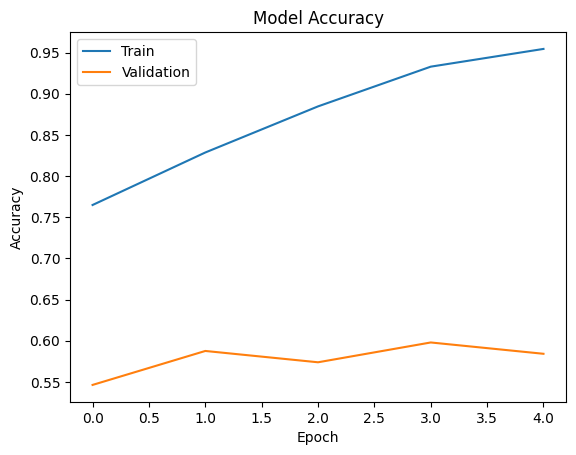

In [31]:
# Evaluation
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(y_test_encode, y_pred))
confusion_matrix(y_test_encode, y_pred)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train','Validation'])
plt.show()